In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV


from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error


data = pd.read_csv("Hitters.csv")
df_hitters = data.copy()
df_hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [ ]:
#categorical varibale
print('The league types are :'  ,df_hitters['League'].unique())
print('The division types are :' , df_hitters['Division'].unique())
print('The new leagues are :' , df_hitters['NewLeague'].unique())

The league types are : ['A' 'N']
The division types are : ['E' 'W']
The new leagues are : ['A' 'N']


In [ ]:
#assiging values to categorical variables
df_hitters_num = pd.get_dummies(df_hitters , columns = ['League' , 'Division' , 'NewLeague'] , drop_first=True , dtype=int)
df_hitters_num

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,NaN,0,0,0
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,1,1,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,0,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,1,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,325,9,3,700.0,1,0,1
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,313,381,20,875.0,0,0,0
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,37,113,7,385.0,0,1,0
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,1314,131,12,960.0,0,0,0


In [ ]:
#checking null
df_hitters_num.isnull().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [ ]:
#droping the null values
df_hitters_num_nonull = df_hitters_num.dropna()
df_hitters_num_nonull.isnull().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


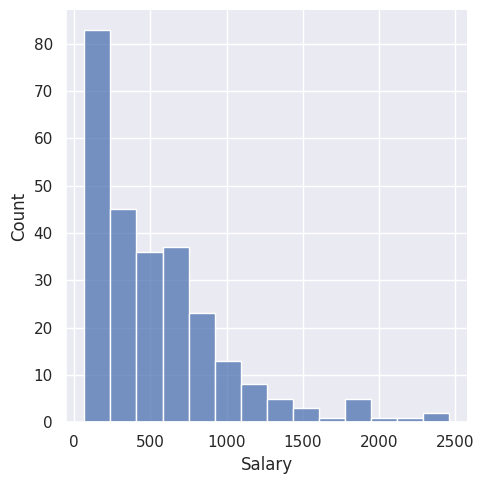

In [ ]:
#plotting the target varbiable to see the distribution of the data
sns.displot(df_hitters_num_nonull['Salary']);

In [ ]:
#seeing the correlation of the target variable with the indepedent variabls
correlation = df_hitters_num_nonull.corr()
correlation['Salary'].sort_values(ascending=True)

,Salary
Division_W,-0.192514
League_N,-0.014282
Errors,-0.005401
NewLeague_N,-0.002834
Assists,0.025436
PutOuts,0.300480
HmRun,0.343028
AtBat,0.394771
Years,0.400657
Runs,0.419859


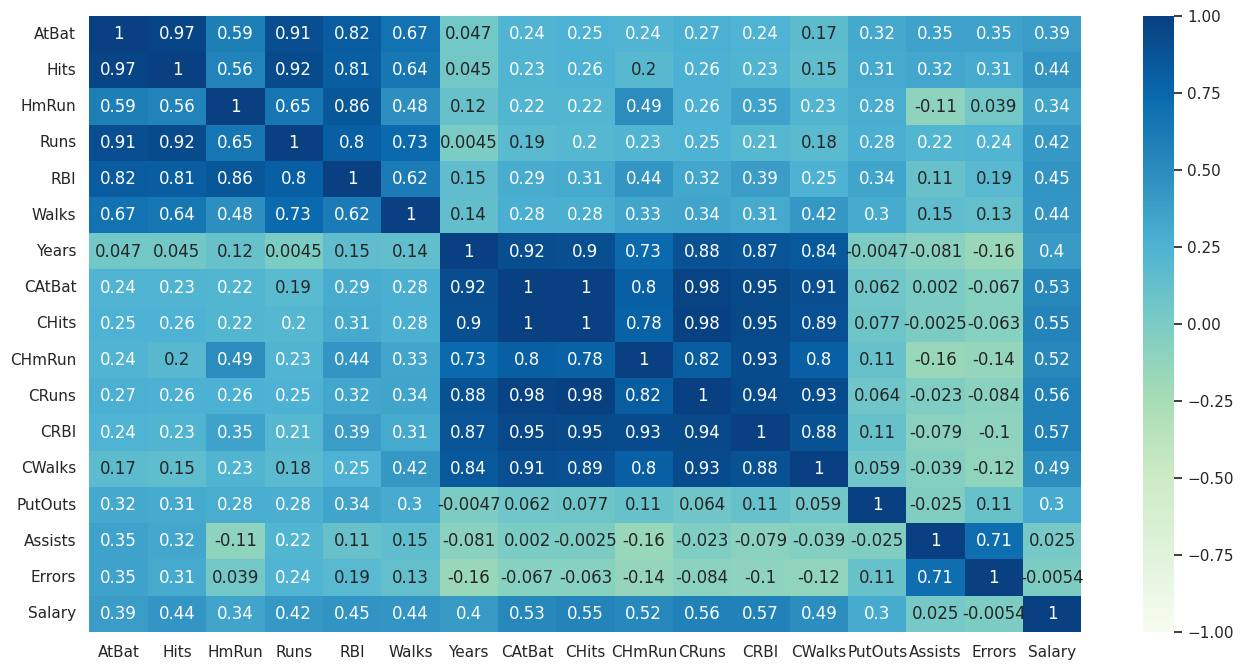

In [ ]:

# Check for multicolinearity
plt.figure(figsize=(16,8))
sns.heatmap(df_hitters.corr(numeric_only=True),
            vmin = -1,
            vmax = 1,
            cmap ="GnBu",
            annot=True)
plt.show()

In [ ]:
#Defineing the target varibale and independent varibale
x = df_hitters_num_nonull.drop('Salary' , axis=1)
y = df_hitters_num_nonull['Salary']

In [ ]:
#split the data into train and test set
x_test , x_train , y_test , y_train = train_test_split(x, y , test_size=0.35 , random_state=365)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
#perform linear regression
lin_reg = LinearRegression()
lin_reg.fit(x_train , y_train)

LinearRegression()

In [ ]:
print('The Coefficient of linear regression are:' , lin_reg.coef_)
print('The intercept of linear regression is:' ,lin_reg.intercept_)

The Coefficient of linear regression are: [ -412.75279387   593.88804289   -24.43725846  -191.29768341
    22.63760105   206.15816819   -79.89859176  1000.16619541
 -1043.47031261   169.03980744   576.05095477  -154.07895712
  -294.79593945    11.5382843    -32.00970626    -4.38946323
   -28.06247094    -7.46984128    45.32642946]
The intercept of linear regression is: 542.5609354838709


In [ ]:
lin_reg_y_pred = lin_reg.predict(x_test)
lin_reg_y_pred

array([ 437.56905501,  672.46816895,  826.62479859,  761.56335162,
        380.74446561,  511.23386553,  323.97832477,  837.20161714,
        309.22142632,  407.14745059, 1060.33823637,  366.60218784,
        712.60367421,  523.1080193 ,  147.90697328,   38.07200481,
       1068.38676697,   85.85353629,  302.61320756,  430.41868779,
        506.64828171,  875.06742641,  840.90538775,  468.72177686,
        461.86449396, 1528.53925436,  630.47941044,  526.45252571,
        546.21665792, 1023.62590764,  -10.46307796, 1046.18245951,
       1098.99892983,  275.9044449 ,  112.66885791,  304.84854331,
        226.90658384,  649.71704104,  157.57531967,  171.68704453,
        573.4284782 ,  -20.55448748, 1085.24027349, 1105.53234023,
        647.34197429,  466.16366068,  193.31834459,  335.51913467,
        551.15736864,  498.90958663,  427.80594617,  580.22568472,
        163.05470041,  574.24834724,  254.00469699,  408.77585471,
        161.58319181,  573.69413272,   67.36735047,  918.55671

In [ ]:
lin_com = pd.DataFrame({'Actual':y_test , 'Predicted':lin_reg_y_pred})
lin_com

,Actual,Predicted
95,595.0,437.569055
23,600.0,672.468169
248,1670.0,826.624799
5,750.0,761.563352
174,450.0,380.744466
...,...,...
194,787.5,774.758101
297,245.0,268.535358
279,150.0,300.762820
226,175.0,28.893861


In [ ]:
print('THE RMSE OF LINEAR REGRESSION MODEL IS:' , math.sqrt(mean_squared_error(y_test , lin_reg_y_pred)))
print('LINEAR MODEL TRAINING SOCRE:' , lin_reg.score(x_train , y_train))
print('LINEAR MODEL TESTING SCORE:' , lin_reg.score(x_test , y_test))

THE RMSE OF LINEAR REGRESSION MODEL IS: 390.7223525857989
LINEAR MODEL TRAINING SOCRE: 0.6544772951370027
LINEAR MODEL TESTING SCORE: 0.34077248633440693


In [ ]:
#PERFORM RIDGE REGRESSION
cv = RepeatedKFold(n_splits=10 , n_repeats=3 , random_state=365)
ridge = RidgeCV(alphas=np.arange(0.1 , 10 , 0.1) , cv=cv , scoring='neg_mean_absolute_error')
ridge.fit(x_train , y_train)
ridge_y_pred = ridge.predict(x_test)
print('RIDGE tunning parameter:' ,(ridge.alpha_))
print('RIDGE model coefficients:' , (ridge.coef_))
print('RIDGE model intercept:' , (ridge.intercept_))

RIDGE tunning parameter: 9.9
RIDGE model coefficients: [-14.31010801 118.77605225 -36.26443442  15.68974386  18.87404125
  84.47790999 -11.65865604  25.199356    36.20104039  79.44721437
  47.07741186  40.3360669  -13.38863227  -6.15523779 -12.09522719
 -31.46353799   2.0433858  -11.258223    24.39592031]
RIDGE model intercept: 542.5609354838709


In [ ]:
print('THE RMSE OF RIDGE REGRESSION MODEL IS:' , math.sqrt(mean_squared_error(y_test , ridge_y_pred)))
print('RIDGE MODEL TRAINING SOCRE:' , ridge.score(x_train , y_train))
print('RIDGE MODEL TESTING SCORE:' , ridge.score(x_test , y_test))

THE RMSE OF RIDGE REGRESSION MODEL IS: 376.60568513019297
RIDGE MODEL TRAINING SOCRE: 0.595748716680094
RIDGE MODEL TESTING SCORE: 0.38754729956172684


In [ ]:
#PERFORMING LASSO REGRESSION
lasso = LassoCV(alphas=np.arange(0.1 , 10 , 0.1) , cv=cv , tol=1 )
lasso.fit(x_train , y_train)
lasso_reg_y_pred = lasso.predict(x_test)

print('Lasso tunning parameter:' , (lasso.alpha_))
print('Lasso model coefficients:' , (lasso.coef_))
print('Lasso model intercept:' , (lasso.intercept_))



print('THE RMSE OF LASSO REGRESSION MODEL IS:' , math.sqrt(mean_squared_error(y_test , lasso_reg_y_pred)))
print('LASSO MODEL TRAINING SOCRE:' , lasso.score(x_train , y_train))
print('LASSO MODEL TESTING SCORE:' , lasso.score(x_test , y_test))


Lasso tunning parameter: 8.9
Lasso model coefficients: [ 1.29362866e+02  4.42636692e+01 -3.92556143e+00  8.06346590e-04
  2.57869726e-02  8.61837044e+01  1.23885193e+02  4.48027982e+01
  8.25303679e+00  2.34642227e+01  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -1.96058627e+01 -3.75019216e+01 -2.54775712e+01
  2.25813452e+01 -0.00000000e+00  3.89912732e+00]
Lasso model intercept: 542.5609354838709
THE RMSE OF LASSO REGRESSION MODEL IS: 404.9593392545011
LASSO MODEL TRAINING SOCRE: 0.5313976778414196
LASSO MODEL TESTING SCORE: 0.2918558873672622


In [ ]:
#COMPARE THE SOCRE

print('LINEAR REGRESSION MODEL TRAINING SCORE:' , lin_reg.score(x_train , y_train))
print('LINEAR REGRESSION MODEL TESTING SCORE:' , lin_reg.score(x_test , y_test))
print('RIDGE REGRESSION MODEL TRAINING SCORE:' , ridge.score(x_train , y_train))
print('RIDGE REGRESSION MODEL TESTING SCORE:' , ridge.score(x_test , y_test))
print('LASSO REGRESSION MODEL TRAINING SCORE:' , lasso.score(x_train , y_train))
print('LASSO REGRESSION MODEL TESTING SCORE:' , lasso.score(x_test , y_test))

LINEAR REGRESSION MODEL TRAINING SCORE: 0.6544772951370027
LINEAR REGRESSION MODEL TESTING SCORE: 0.34077248633440693
RIDGE REGRESSION MODEL TRAINING SCORE: 0.595748716680094
RIDGE REGRESSION MODEL TESTING SCORE: 0.38754729956172684
LASSO REGRESSION MODEL TRAINING SCORE: 0.5313976778414196
LASSO REGRESSION MODEL TESTING SCORE: 0.2918558873672622


In [ ]:
#COMPARE THE ROOT MEAN SQUARE ERROR
print('THE RMSE OF LINEAR REGRESSION MODEL IS:' , math.sqrt(mean_squared_error(y_test , lin_reg_y_pred)))
print('THE RMSE OF RIDGE REGRESSION MODEL IS:' , math.sqrt(mean_squared_error(y_test , ridge_y_pred)))
print('THE RMSE OF LASSO REGRESSION MODEL IS:' , math.sqrt(mean_squared_error(y_test , lasso_reg_y_pred)))

THE RMSE OF LINEAR REGRESSION MODEL IS: 390.7223525857989
THE RMSE OF RIDGE REGRESSION MODEL IS: 376.60568513019297
THE RMSE OF LASSO REGRESSION MODEL IS: 404.9593392545011


In [ ]:
#REPLACING THE MISSIGN VALUES IN DATA FRAME
df_hitters_nun = df_hitters_num[df_hitters_num['Salary'].isnull()]
df_hitters_nun

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,NaN,0,0,0
15,183,39,3,20,15,11,3,201,42,3,20,16,11,118,0,0,NaN,0,1,0
18,407,104,6,57,43,65,12,5233,1478,100,643,658,653,912,88,9,NaN,0,1,0
22,22,10,1,4,2,1,6,84,26,2,9,9,3,812,84,11,NaN,0,1,0
30,313,84,9,42,30,39,17,6890,1833,224,1033,864,1087,127,221,7,NaN,0,1,0
32,517,141,27,70,87,52,9,3571,994,215,545,652,337,1378,102,8,NaN,1,1,1
36,161,36,0,19,10,17,4,1053,244,3,156,86,107,70,149,12,NaN,0,0,0
38,346,98,5,31,53,30,16,5913,1615,235,784,901,560,0,0,0,NaN,0,0,0
39,241,61,1,34,12,14,1,241,61,1,34,12,14,166,172,10,NaN,1,1,1
41,216,54,0,21,18,15,18,7318,1926,46,796,627,483,103,84,5,NaN,1,1,1


In [ ]:
x_nan = df_hitters_nun.drop('Salary' , axis=1)
x_nan

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,0,0,0
15,183,39,3,20,15,11,3,201,42,3,20,16,11,118,0,0,0,1,0
18,407,104,6,57,43,65,12,5233,1478,100,643,658,653,912,88,9,0,1,0
22,22,10,1,4,2,1,6,84,26,2,9,9,3,812,84,11,0,1,0
30,313,84,9,42,30,39,17,6890,1833,224,1033,864,1087,127,221,7,0,1,0
32,517,141,27,70,87,52,9,3571,994,215,545,652,337,1378,102,8,1,1,1
36,161,36,0,19,10,17,4,1053,244,3,156,86,107,70,149,12,0,0,0
38,346,98,5,31,53,30,16,5913,1615,235,784,901,560,0,0,0,0,0,0
39,241,61,1,34,12,14,1,241,61,1,34,12,14,166,172,10,1,1,1
41,216,54,0,21,18,15,18,7318,1926,46,796,627,483,103,84,5,1,1,1


In [ ]:
scaler = StandardScaler()
x_nan = scaler.fit_transform(x_nan)
nan_predict = ridge.predict(x_nan)
nan_predict

array([ 210.38114158,  222.44377389,  898.3947044 ,  -28.08246324,
        871.39700533,  984.2994776 ,  204.89012509,  996.33058367,
        271.83450728,  627.49302987,  463.18747958,  517.88219706,
       1154.06788769,   99.94218701,  509.41399269,   71.76617708,
        257.55859448,  834.02526279,  361.51912763,  495.87897907,
       1084.53820054,  301.60822749,  445.04562578,  665.20362615,
        576.06137437,  615.42592492, 1085.73509856,  163.62602668,
        498.87515004, 1010.25237835,  890.94529488,  450.60270177,
        508.88451582,  426.78457408,  576.02361463,  799.72127027,
        257.12905468,  436.74664071,  275.73947135,  311.15310582,
        244.21638836,  836.205433  ,  440.0439976 ,  437.1433348 ,
        514.24631952,  580.87164004,  662.33940791,  961.56620177,
        655.31342017,   75.02403943,  279.44449969,  566.01441717,
        463.64380088,   17.96566666,  853.60190402,  258.65790029,
       1120.52295109, 1255.92445869,  383.62376499])

In [ ]:
df_nan_full = df_hitters_nun.copy()
df_nan_full['Salary'] = nan_predict
df_nan_full

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,210.381142,0,0,0
15,183,39,3,20,15,11,3,201,42,3,20,16,11,118,0,0,222.443774,0,1,0
18,407,104,6,57,43,65,12,5233,1478,100,643,658,653,912,88,9,898.394704,0,1,0
22,22,10,1,4,2,1,6,84,26,2,9,9,3,812,84,11,-28.082463,0,1,0
30,313,84,9,42,30,39,17,6890,1833,224,1033,864,1087,127,221,7,871.397005,0,1,0
32,517,141,27,70,87,52,9,3571,994,215,545,652,337,1378,102,8,984.299478,1,1,1
36,161,36,0,19,10,17,4,1053,244,3,156,86,107,70,149,12,204.890125,0,0,0
38,346,98,5,31,53,30,16,5913,1615,235,784,901,560,0,0,0,996.330584,0,0,0
39,241,61,1,34,12,14,1,241,61,1,34,12,14,166,172,10,271.834507,1,1,1
41,216,54,0,21,18,15,18,7318,1926,46,796,627,483,103,84,5,627.493030,1,1,1
